In [2]:

# If you do not use colab, install packages if needed.
# !pip install numpy pandas matplotlib scikit-learn graphviz


In [3]:

%matplotlib inline
%reload_ext autoreload
%autoreload 2


## 1. Complete `model/metrics.py`

In [4]:
from pathlib import Path

metrics_file = Path('model/metrics.py')

completed_metrics_code = '''
import numpy as np
from model.utils import onehot_array
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
import matplotlib.pyplot as plt

# Here is a loss function for linear regression
def MSE(y, y_pred):
    return np.mean((y_pred - y) ** 2)

def MAE(y, y_pred):
    """
    Mean Absolute Error Loss
    """
    return np.mean(np.abs(y_pred - y))

# Here is a loss function for logistic regression
def logloss(y, y_pred):
    y_pred = np.clip(y_pred, 1e-5, 1 - 1e-5)
    return np.mean(-np.log(y_pred) * y - np.log(1 - y_pred) * (1 - y))

#-----------------------------------------------------------------#

# Here is the evalution function for linear regression
def evaluate_linear_regression(y_true, y_pred, title='Linear Regression Evaluation'):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    metrics = {
        'MSE': mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R-squared': r2_score(y_true, y_pred),
    }

    print(f"=== {title} ===")
    for name, value in metrics.items():
        print(f'{name:<10}: {value:.4f}')

    return metrics

# Here is the evalution function for logistic regression
def evaluate_binary_classifier(y_true, y_pred, title='Model Evaluation'):
    y_true = np.asarray(y_true).ravel().astype(int)
    y_pred = np.asarray(y_pred).ravel().astype(int)

    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0)
    }

    print(title)
    for name, value in metrics.items():
        print(f'{name:<10}: {value:.4f}')

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(8, 4.2))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title('Confusion Matrix')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    return metrics
'''.strip() + "\n"

if metrics_file.exists():
    metrics_file.write_text(completed_metrics_code, encoding='utf-8')
    print(f'Updated: {metrics_file}')
else:
    print('Warning: model/metrics.py was not found in the current folder.')

Updated: model\metrics.py


## 2. Import packages and helper functions

In [5]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model.metrics import MSE, evaluate_linear_regression
from model.gradients import MSE_grad
from model.linear_model import LinearModel
from model.utils import get_train_val


## 3. Experiment settings

In [6]:

seed = 42   # do not change the seed
learning_rates = [0.1, 0.01, 0.001]
datasets = ['linear_data_A', 'linear_data_B', 'linear_data_C', 'linear_data_D']
n_iteration = 500


## 4. Run all experiments

In [7]:

def run_one_experiment(dataset_name, lr, n_iteration=500):
    loaded_data = np.load(f'data/linear_data/{dataset_name}.npz')
    X = loaded_data['X_data']
    y = loaded_data['y_data']

    dim = X.shape[1] - 1

    np.random.seed(seed)
    X_train, y_train, X_val, y_val = get_train_val(X, y)

    model = LinearModel(dim, True, MSE, MSE_grad)

    print('=' * 90)
    print(f'Dataset: {dataset_name} | learning rate: {lr}')
    print(f'X size: {X.shape}, y size: {y.shape}, dim: {dim}')

    # model.fit will print the training/validation loss during training.
    # In the original notebook, it also shows the loss curve figure.
    model.fit(X_train, y_train, lr=lr, n_iteration=n_iteration, val_ratio=0.2)

    y_val_pred = model.predict(X_val)
    metrics = evaluate_linear_regression(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'{dataset_name} | lr={lr}'
    )

    record = {
        'dataset': dataset_name,
        'learning_rate': lr,
        'MSE': metrics['MSE'],
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'R-squared': metrics['R-squared']
    }
    return record


In [12]:
def run_one_experiment(dataset_name, lr, n_iteration=500):
    loaded_data = np.load(f'data/linear_data/{dataset_name}.npz')
    X = loaded_data['X_data']
    y = loaded_data['y_data']

    dim = X.shape[1] - 1

    np.random.seed(seed)
    X_train, y_train, X_val, y_val = get_train_val(X, y)

    model = LinearModel(dim, True, MSE, MSE_grad)

    print('=' * 90)
    print(f'Dataset: {dataset_name} | learning rate: {lr}')
    print(f'X size: {X.shape}, y size: {y.shape}, dim: {dim}')

    model.fit(X_train, y_train, lr=lr, n_iteration=n_iteration, val_ratio=0.2)

    y_val_pred = model.predict(X_val)
    metrics = evaluate_linear_regression(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'{dataset_name} | lr={lr}'
    )

    record = {
        'dataset': dataset_name,
        'learning_rate': lr,
        'MSE': metrics['MSE'],
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'R-squared': metrics['R-squared'],
        'X_val': X_val,
        'y_val': y_val,
        'y_val_pred': y_val_pred
    }
    return record

Dataset: linear_data_A | learning rate: 0.1
X size: (1600, 2), y size: (1600,), dim: 1
50. Training loss: 0.013423623061455565, Val loss:0.012580010701461058
100. Training loss: 0.013423622480987135, Val loss:0.012580089713127157
150. Training loss: 0.013423622480987133, Val loss:0.012580089715050587
200. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
250. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
300. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
350. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
400. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
450. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
500. Training loss: 0.013423622480987133, Val loss:0.012580089715050636


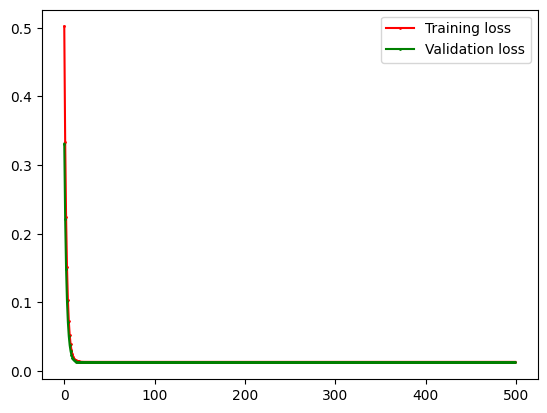

=== linear_data_A | lr=0.1 ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690
Dataset: linear_data_A | learning rate: 0.01
X size: (1600, 2), y size: (1600,), dim: 1
50. Training loss: 0.08822499761459246, Val loss:0.08344253861678516
100. Training loss: 0.024461533163063473, Val loss:0.022730598385935285
150. Training loss: 0.015054341888577384, Val loss:0.013961184271627123
200. Training loss: 0.013664791563666538, Val loss:0.012739408114859366
250. Training loss: 0.013459321509937406, Val loss:0.012586753610002822
300. Training loss: 0.013428910982968287, Val loss:0.012574716912916001
350. Training loss: 0.013424406462249211, Val loss:0.01257690199190865
400. Training loss: 0.013423738769333433, Val loss:0.012578717009069202
450. Training loss: 0.013423639738964216, Val loss:0.012579546976647175
500. Training loss: 0.013423625043327498, Val loss:0.01257988125786218


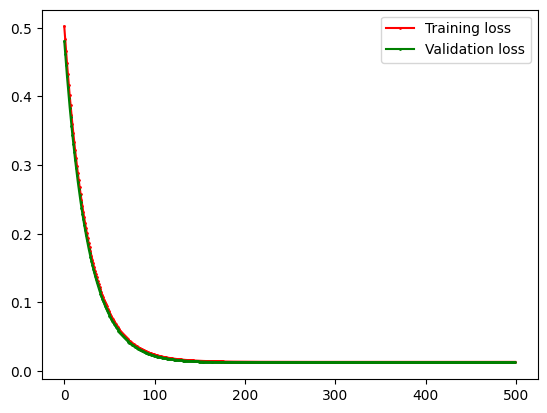

=== linear_data_A | lr=0.01 ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690
Dataset: linear_data_A | learning rate: 0.001
X size: (1600, 2), y size: (1600,), dim: 1
50. Training loss: 0.418984925274338, Val loss:0.41420880497204005
100. Training loss: 0.34884281364937003, Val loss:0.3445251797643867
150. Training loss: 0.2908358402579774, Val loss:0.28691334687110626
200. Training loss: 0.2428637953466062, Val loss:0.23928338706190336
250. Training loss: 0.20319008395293756, Val loss:0.19990713434668128
300. Training loss: 0.17037874765339453, Val loss:0.16735555250253287
350. Training loss: 0.14324239869173933, Val loss:0.1404469551481651
400. Training loss: 0.12079917484937551, Val loss:0.11820419110090803
450. Training loss: 0.10223715148116824, Val loss:0.09981924222927965
500. Training loss: 0.08688491828078371, Val loss:0.08462395006505144


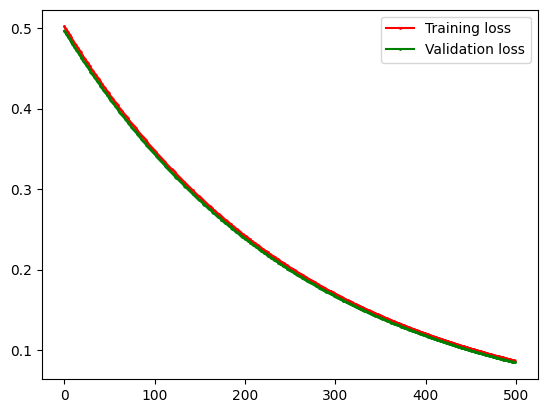

=== linear_data_A | lr=0.001 ===
MSE       : 0.0832
MAE       : 0.2369
RMSE      : 0.2884
R-squared : -1.6836
Dataset: linear_data_B | learning rate: 0.1
X size: (1600, 2), y size: (1600,), dim: 1
50. Training loss: 0.21477796029761928, Val loss:0.20128111574984853
100. Training loss: 0.21477795969579408, Val loss:0.20128143543301202
150. Training loss: 0.2147779596957941, Val loss:0.20128143544080995
200. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
250. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
300. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
350. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
400. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
450. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
500. Training loss: 0.21477795969579408, Val loss:0.20128143544081017


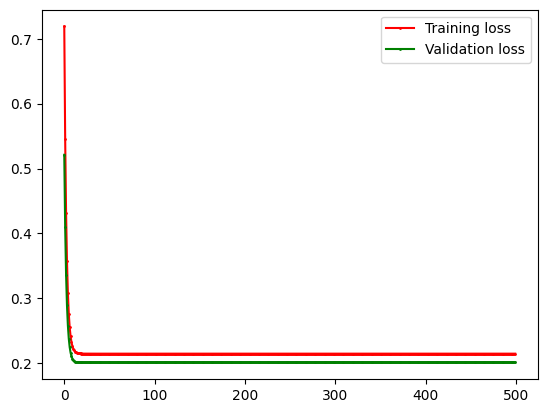

=== linear_data_B | lr=0.1 ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448
Dataset: linear_data_B | learning rate: 0.01
X size: (1600, 2), y size: (1600,), dim: 1
50. Training loss: 0.2920213425997664, Val loss:0.2702611408646165
100. Training loss: 0.22618379407532826, Val loss:0.2101879308116208
150. Training loss: 0.2164640141651331, Val loss:0.2021155812609517
200. Training loss: 0.21502743867502366, Val loss:0.20122361991141446
250. Training loss: 0.21481490508468085, Val loss:0.20120482979710497
300. Training loss: 0.21478343493349927, Val loss:0.20124452118342356
350. Training loss: 0.21477877162933798, Val loss:0.20126634873684507
400. Training loss: 0.21477808016505961, Val loss:0.20127557772119783
450. Training loss: 0.21477797757871428, Val loss:0.20127920153421996
500. Training loss: 0.2147779623514954, Val loss:0.20128058874123028


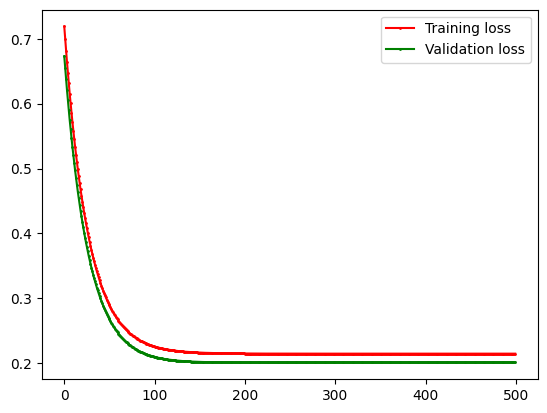

=== linear_data_B | lr=0.01 ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448
Dataset: linear_data_B | learning rate: 0.001
X size: (1600, 2), y size: (1600,), dim: 1
50. Training loss: 0.6333011463329974, Val loss:0.605763731465133
100. Training loss: 0.560944176029853, Val loss:0.5347780170370382
150. Training loss: 0.5011005997675119, Val loss:0.47616215994096633
200. Training loss: 0.4516056474010014, Val loss:0.4277683253433776
250. Training loss: 0.41066917554133203, Val loss:0.3878209660417229
300. Training loss: 0.37681081233745717, Val loss:0.354852342304647
350. Training loss: 0.3488063343172151, Val loss:0.32764920718227697
400. Training loss: 0.32564332924740713, Val loss:0.3052087237083346
450. Training loss: 0.30648453628529515, Val loss:0.28670201534712025
500. Training loss: 0.2906375335120469, Val loss:0.27144402793270805


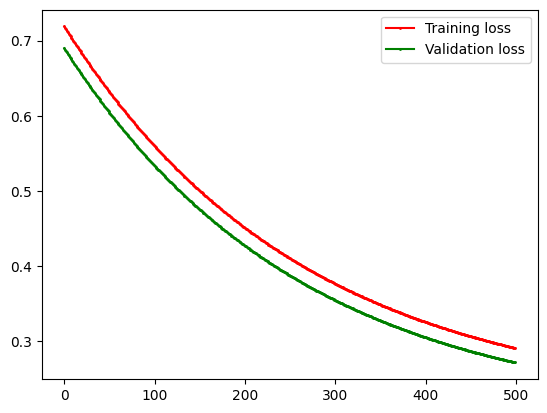

=== linear_data_B | lr=0.001 ===
MSE       : 0.2687
MAE       : 0.4404
RMSE      : 0.5184
R-squared : -0.2011
Dataset: linear_data_C | learning rate: 0.1
X size: (8000, 6), y size: (8000,), dim: 5
50. Training loss: 0.0131818971313023, Val loss:0.013771656751385359
100. Training loss: 0.013181896123422132, Val loss:0.013771595669720494
150. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
200. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
250. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
300. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
350. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
400. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
450. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
500. Training loss: 0.013181896123422132, Val loss:0.013771595669175307


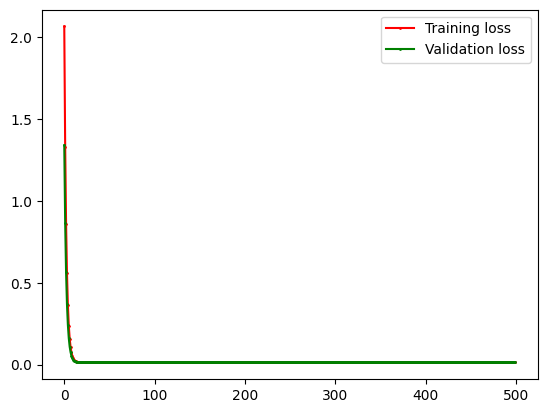

=== linear_data_C | lr=0.1 ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954
Dataset: linear_data_C | learning rate: 0.01
X size: (8000, 6), y size: (8000,), dim: 5
50. Training loss: 0.3016776572102272, Val loss:0.2940364008397445
100. Training loss: 0.052301281914569585, Val loss:0.052286225702638675
150. Training loss: 0.018505850726527058, Val loss:0.019175412162323584
200. Training loss: 0.013908983721033275, Val loss:0.014564896297918123
250. Training loss: 0.013281521987973383, Val loss:0.013899712449279154
300. Training loss: 0.01319558969139006, Val loss:0.013796096535113092
350. Training loss: 0.013183783898695744, Val loss:0.013777427806772765
400. Training loss: 0.013182157103470477, Val loss:0.013773277022245267
450. Training loss: 0.013181932299897786, Val loss:0.013772140690770074
500. Training loss: 0.013181901150900593, Val loss:0.013771782558303799


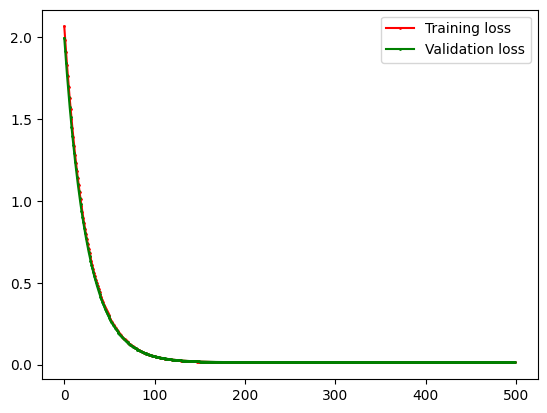

=== linear_data_C | lr=0.01 ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954
Dataset: linear_data_C | learning rate: 0.001
X size: (8000, 6), y size: (8000,), dim: 5
50. Training loss: 1.7022307356186879, Val loss:1.704399561902757
100. Training loss: 1.398099093422373, Val loss:1.4007211470145513
150. Training loss: 1.1487734111234604, Val loss:1.1516658664027397
200. Training loss: 0.9443693636081101, Val loss:0.9473976449419805
250. Training loss: 0.7767867515803092, Val loss:0.7798533335010577
300. Training loss: 0.6393871949572303, Val loss:0.642422853410673
350. Training loss: 0.5267301015086948, Val loss:0.5296870971374619
400. Training loss: 0.4343563650291918, Val loss:0.43720314708376423
450. Training loss: 0.3586111574044348, Val loss:0.3613282625111077
500. Training loss: 0.29649874274023047, Val loss:0.299075630842221


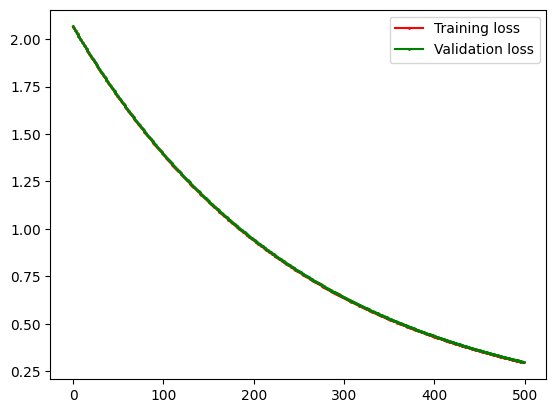

=== linear_data_C | lr=0.001 ===
MSE       : 0.2852
MAE       : 0.4273
RMSE      : 0.5341
R-squared : 0.8994
Dataset: linear_data_D | learning rate: 0.1
X size: (8000, 6), y size: (8000,), dim: 5
50. Training loss: 0.08238685177710688, Val loss:0.08607262493707105
100. Training loss: 0.08238685077138833, Val loss:0.08607247293371127
150. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
200. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
250. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
300. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
350. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
400. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
450. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
500. Training loss: 0.08238685077138833, Val loss:0.0860724729323457


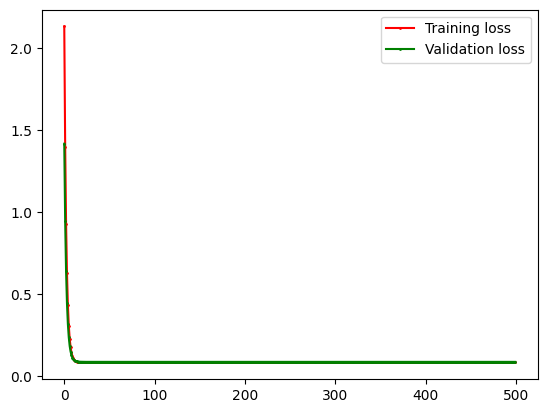

=== linear_data_D | lr=0.1 ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716
Dataset: linear_data_D | learning rate: 0.01
X size: (8000, 6), y size: (8000,), dim: 5
50. Training loss: 0.3703643487722047, Val loss:0.3686849563983318
100. Training loss: 0.1214345969859307, Val loss:0.1255385955779745
150. Training loss: 0.08770086474185745, Val loss:0.09183236776167002
200. Training loss: 0.08311255449810843, Val loss:0.08699540377230673
250. Training loss: 0.0824862834452406, Val loss:0.08624729244656879
300. Training loss: 0.08240051730594523, Val loss:0.08611372904350847
350. Training loss: 0.08238873475630884, Val loss:0.08608430475529508
400. Training loss: 0.0823871112191, Val loss:0.08607630029028919
450. Training loss: 0.0823868868729943, Val loss:0.08607378489771042
500. Training loss: 0.0823868557883243, Val loss:0.08607293368416795


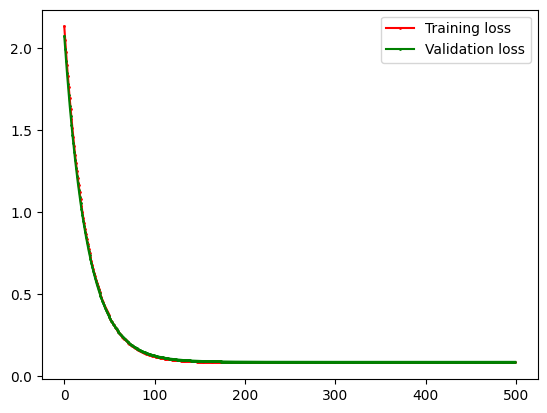

=== linear_data_D | lr=0.01 ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716
Dataset: linear_data_D | learning rate: 0.001
X size: (8000, 6), y size: (8000,), dim: 5
50. Training loss: 1.7684511643778449, Val loss:1.7808955296769526
100. Training loss: 1.4648524964143852, Val loss:1.4770554865390984
150. Training loss: 1.2159645145907354, Val loss:1.2278106296911493
200. Training loss: 1.0119199428934709, Val loss:1.0233353741451867
250. Training loss: 0.8446325767970521, Val loss:0.8555746535033422
300. Training loss: 0.7074755244845349, Val loss:0.7179245466593898
350. Training loss: 0.5950176249327075, Val loss:0.6049705693586136
400. Training loss: 0.50280751484024, Val loss:0.5122732093945561
450. Training loss: 0.4271967232656893, Val loss:0.43619216922708653
500. Training loss: 0.3651947340371162, Val loss:0.3737423235472047


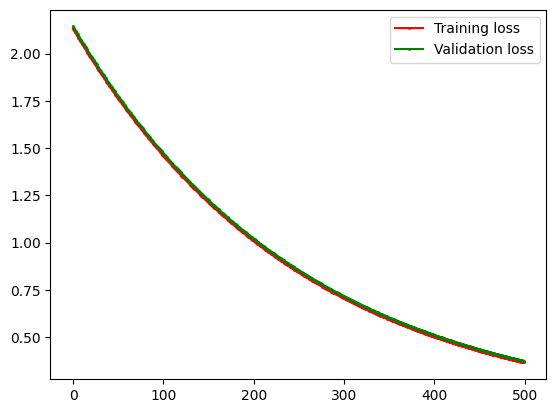

=== linear_data_D | lr=0.001 ===
MSE       : 0.3540
MAE       : 0.4778
RMSE      : 0.5950
R-squared : 0.8780


In [13]:
all_results = []

for dataset_name in datasets:
    for lr in learning_rates:
        result = run_one_experiment(dataset_name, lr, n_iteration=n_iteration)
        all_results.append(result)

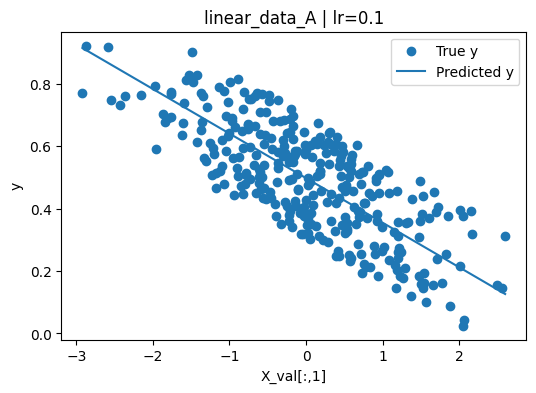

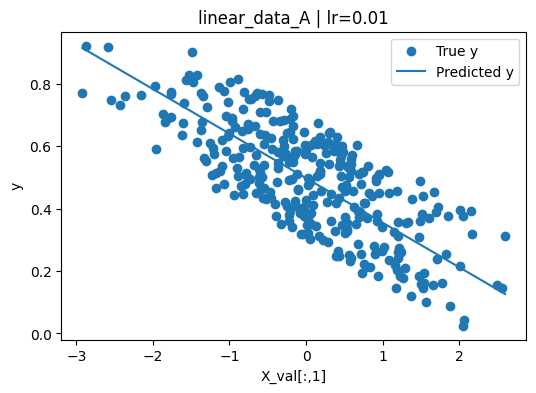

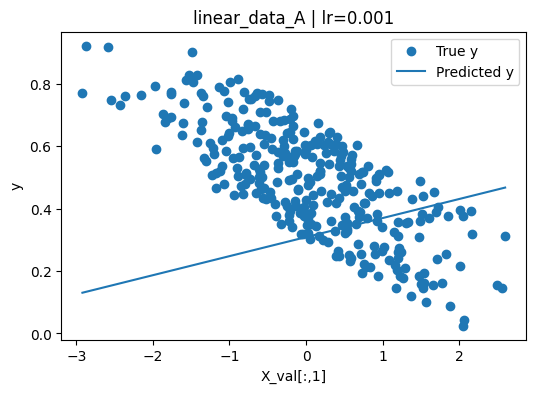

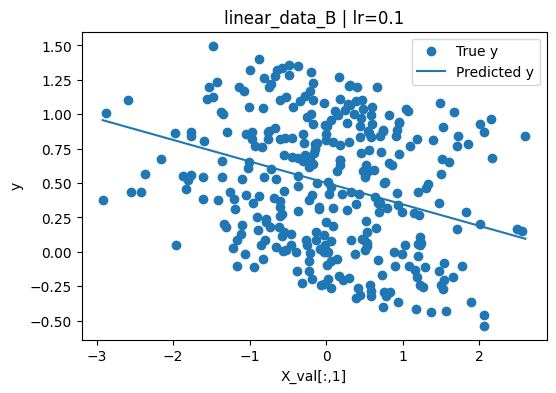

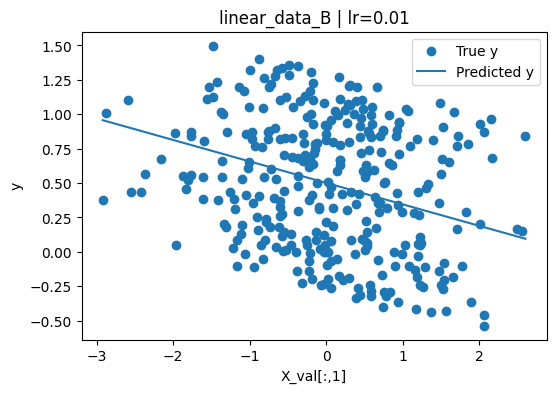

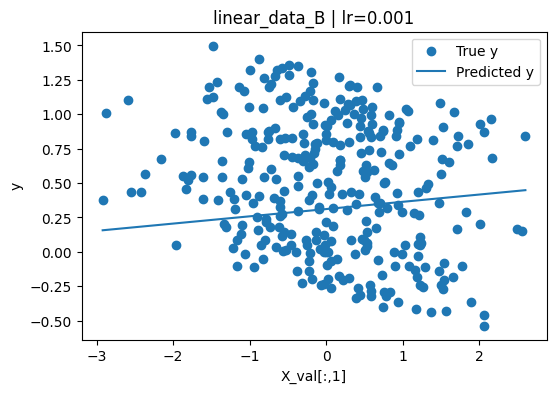

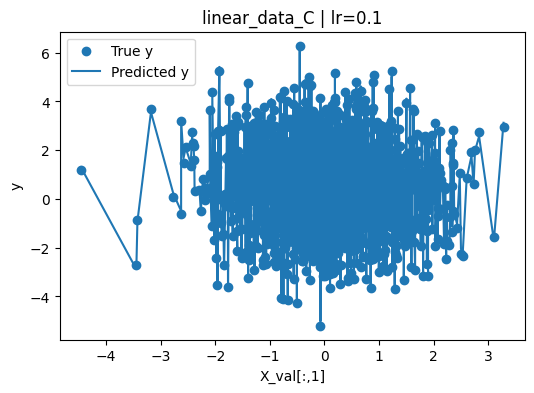

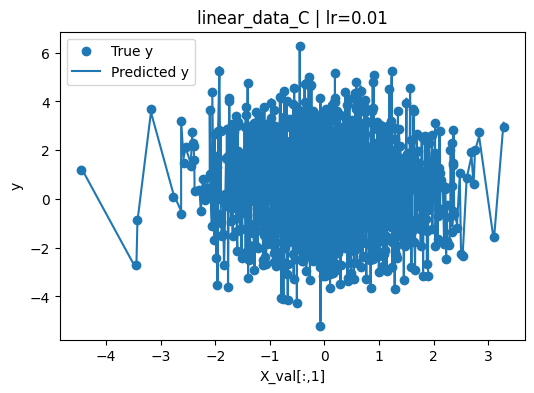

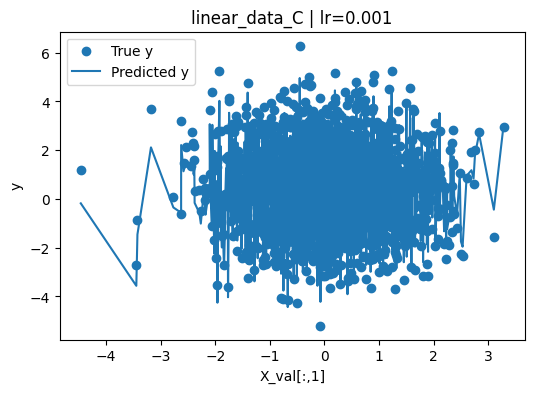

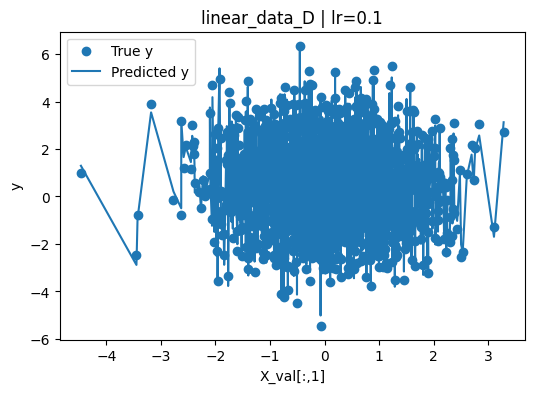

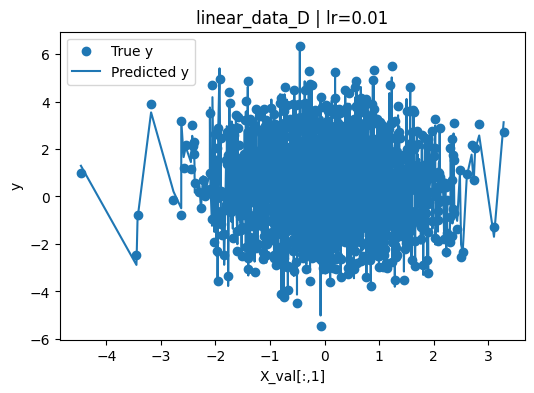

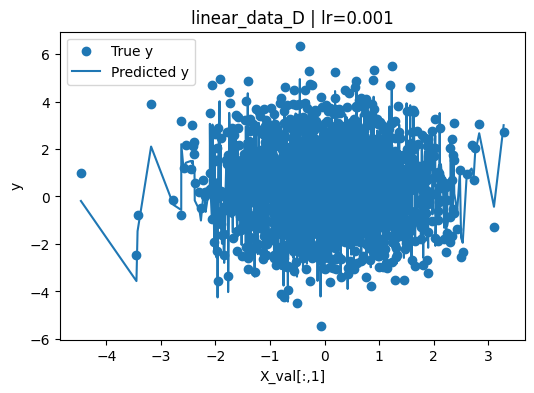

In [14]:
for result in all_results:
    X_val = result['X_val']
    y_val = result['y_val']
    y_val_pred = result['y_val_pred']

    sort_idx = np.argsort(X_val[:, 1])

    plt.figure(figsize=(6, 4))
    plt.scatter(X_val[:, 1], y_val, label='True y')
    plt.plot(X_val[:, 1][sort_idx], y_val_pred[sort_idx], label='Predicted y')
    plt.title(f"{result['dataset']} | lr={result['learning_rate']}")
    plt.xlabel("X_val[:,1]")
    plt.ylabel("y")
    plt.legend()
    plt.show()

## 5. Summary table of evaluation results

In [ ]:

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(['dataset', 'learning_rate']).reset_index(drop=True)
results_df


,dataset,learning_rate,MSE,MAE,RMSE,R-squared
0,linear_data_A,0.001,0.083156,0.236918,0.288369,-1.683627
1,linear_data_A,0.010,0.013355,0.100951,0.115565,0.569000
2,linear_data_A,0.100,0.013356,0.100956,0.115570,0.568964
3,linear_data_B,0.001,0.268702,0.440391,0.518365,-0.201071
4,linear_data_B,0.010,0.213697,0.403819,0.462274,0.044796
5,linear_data_B,0.100,0.213701,0.403824,0.462278,0.044775
6,linear_data_C,0.001,0.285225,0.427349,0.534065,0.899428
7,linear_data_C,0.010,0.013183,0.098681,0.114817,0.995352
8,linear_data_C,0.100,0.013183,0.098682,0.114816,0.995352
9,linear_data_D,0.001,0.354014,0.477794,0.594991,0.877998


## 6. Best learning rate by dataset (based on lowest validation MSE)

In [ ]:

best_by_mse = results_df.loc[results_df.groupby('dataset')['MSE'].idxmin()].reset_index(drop=True)
best_by_mse


,dataset,learning_rate,MSE,MAE,RMSE,R-squared
0,linear_data_A,0.01,0.013355,0.100951,0.115565,0.569000
1,linear_data_B,0.01,0.213697,0.403819,0.462274,0.044796
2,linear_data_C,0.10,0.013183,0.098682,0.114816,0.995352
3,linear_data_D,0.10,0.082392,0.246706,0.287041,0.971606
